# Credit Card Fraud Detection using Ensemble Learning

---

# Project Overview

Credit card fraud detection is a critical financial security problem where fraudulent transactions must be identified accurately while minimizing false alerts for genuine customers.

This project builds a machine learning-based fraud detection system using ensemble learning algorithms to classify transactions as legitimate or fraudulent.

Since fraud detection is a highly imbalanced classification problem, the project focuses not only on predictive accuracy, but also on improving fraud recall, reducing false negatives, and evaluating business impact.

The project also includes:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Cross-validation
- Hyperparameter tuning
- Threshold optimization
- Explainable AI using SHAP
- Interactive deployment using Streamlit

---

# Project Objectives

The major objectives of this project are:

- Detect fraudulent credit card transactions
- Handle class imbalance effectively
- Compare ensemble learning algorithms
- Improve fraud detection recall
- Optimize classification thresholds
- Evaluate business-oriented fraud detection performance
- Build an interactive fraud detection application

---

# Ensemble Learning Models Used

The following ensemble learning algorithms were implemented and compared:

## Random Forest

A bagging-based ensemble algorithm that combines multiple decision trees to improve stability and reduce overfitting.

## Gradient Boosting

A boosting algorithm that sequentially improves prediction performance by minimizing previous errors.

## XGBoost

An optimized gradient boosting algorithm known for high performance, regularization capability, and efficient handling of structured data.

---

# Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- XGBoost
- Matplotlib
- Seaborn
- SHAP
- Streamlit

# Step 1: Importing Libraries and Loading Dataset

In this step, the required Python libraries for data manipulation, visualization, machine learning, and model evaluation are imported.

These libraries will be used throughout the project for:

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Model training
- Performance evaluation
- Visualization
- Explainable AI

The credit card fraud detection dataset is then loaded into a Pandas DataFrame for further analysis.

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("credit_card_fraud.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


The dataset contains transaction-related information such as transaction amount, merchant category, transaction velocity, device trust score, and location mismatch indicators.

The target variable is:

- `0` → Legitimate Transaction
- `1` → Fraudulent Transaction

# Step 2: Initial Dataset Exploration

In this step, we analyze the structure of the dataset to better understand:

- Feature names and data types
- Missing values
- Distribution of fraud and non-fraud transactions

This helps identify data quality issues and understand the class imbalance problem commonly found in fraud detection systems.

In [3]:
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['is_fraud'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 851.2 KB

Missing Values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
i

## Observations

The dataset contains 10,000 transaction records and 10 features, including both numerical and categorical variables.

Key observations from the initial exploration include:

- No missing values were found in the dataset
- Most features are numerical, while `merchant_category` is categorical
- The target variable is `is_fraud`
- The dataset is highly imbalanced

Class distribution:

- Legitimate Transactions (`0`) → 9849
- Fraudulent Transactions (`1`) → 151

This severe class imbalance indicates that accuracy alone may not be a reliable evaluation metric, since a model predicting all transactions as legitimate could still achieve very high accuracy.

Therefore, metrics such as Precision, Recall, F1-Score, ROC-AUC, and Precision-Recall analysis will be prioritized during model evaluation.

# Step 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand transaction behavior, identify fraud-related patterns, and analyze relationships between different features.

EDA helps in:

- Understanding class imbalance
- Identifying important fraud indicators
- Detecting feature relationships
- Analyzing transaction patterns

Since fraud detection is a highly imbalanced classification problem, visual analysis is important for understanding how fraudulent transactions differ from legitimate transactions.

## 1. Class Distribution Analysis

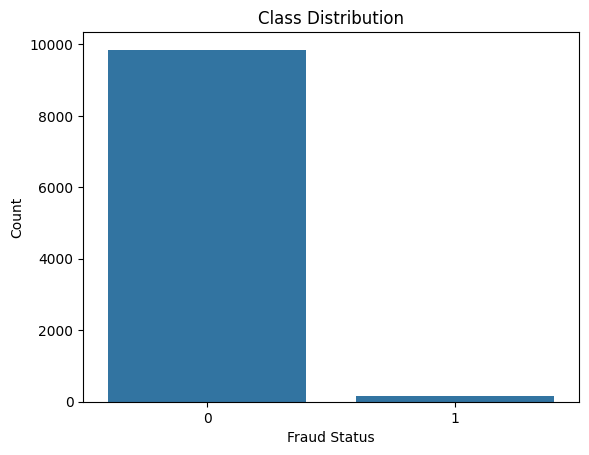

In [4]:
sns.countplot(x='is_fraud', data=df)

plt.title("Class Distribution")
plt.xlabel("Fraud Status")
plt.ylabel("Count")

plt.show()

### Observation

The class distribution plot clearly shows a severe imbalance between legitimate and fraudulent transactions.

Legitimate transactions (`0`) constitute the vast majority of the dataset, while fraudulent transactions (`1`) represent only a very small proportion of total transactions.

This imbalance can cause machine learning models to become biased toward the majority class, resulting in misleadingly high accuracy despite poor fraud detection capability.

Therefore, evaluation metrics such as:

- Recall
- F1-Score
- ROC-AUC
- Precision-Recall Curve

are more appropriate than accuracy alone for assessing fraud detection performance.

## 2. Feature Correlation Heatmap

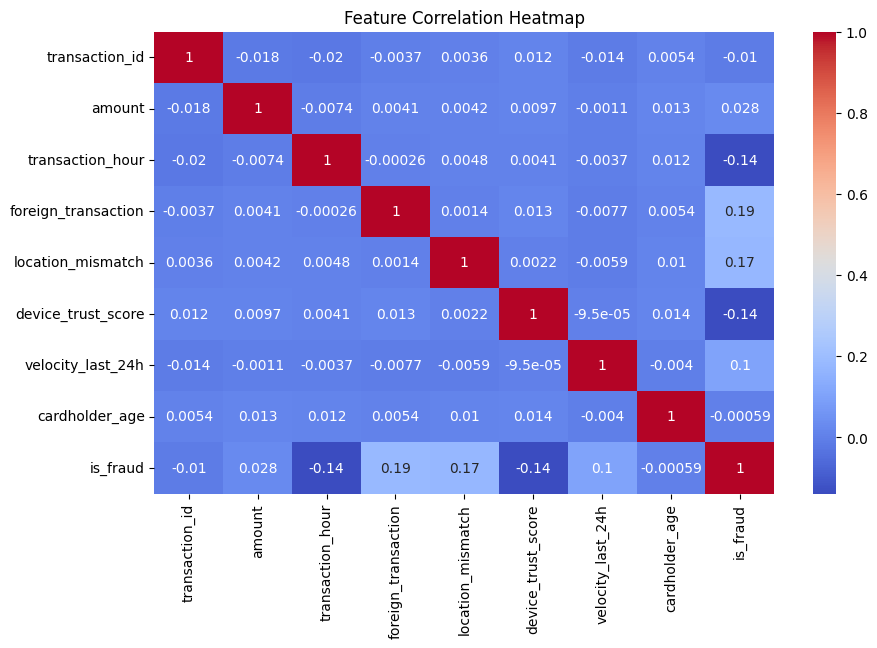

In [5]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap helps identify relationships between transaction-related features and fraudulent activity.

Key observations include:

- `foreign_transaction` shows a positive correlation with fraud, indicating that international transactions are more likely to be fraudulent.
- `location_mismatch` also demonstrates a positive relationship with fraud cases.
- `velocity_last_24h` has a moderate positive correlation, suggesting that unusually high transaction frequency may indicate suspicious activity.
- `device_trust_score` shows a negative correlation with fraud, meaning lower trust scores are associated with higher fraud risk.
- `transaction_hour` also exhibits a slight negative relationship with fraudulent transactions.

Although individual correlations are relatively moderate, multiple features together may help ensemble learning models effectively capture complex fraud patterns.

## 3. Transaction Amount Distribution

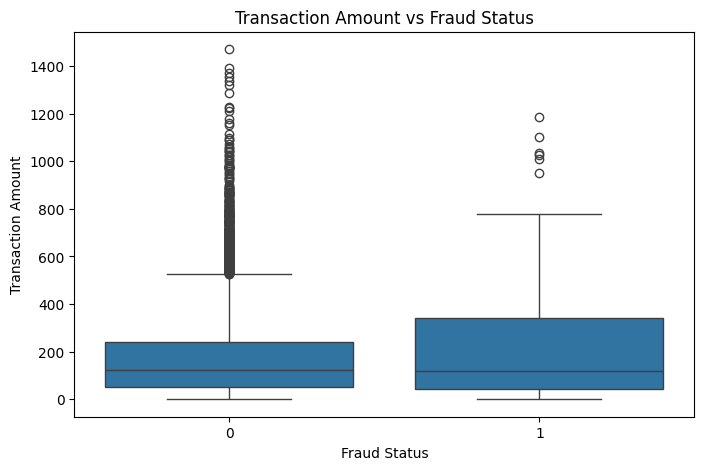

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='is_fraud', y='amount', data=df)

plt.title("Transaction Amount vs Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")

plt.show()

### Observation

The boxplot compares transaction amount distributions between legitimate and fraudulent transactions.

Key observations include:

- Fraudulent transactions exhibit a wider spread in transaction amounts
- The median transaction amount for fraud cases appears slightly higher than legitimate transactions
- Fraud transactions show greater variability, indicating inconsistent spending behavior
- Both classes contain outliers, but unusually large transaction amounts may contribute to fraud detection

These patterns suggest that transaction amount can provide useful predictive information when combined with other behavioral features.

## 4. Foreign Transaction Analysis

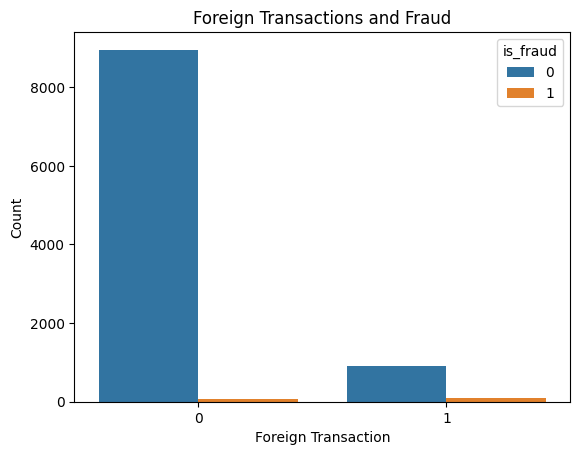

In [7]:
sns.countplot(x='foreign_transaction', hue='is_fraud', data=df)

plt.title("Foreign Transactions and Fraud")
plt.xlabel("Foreign Transaction")
plt.ylabel("Count")

plt.show()

### Observation

The countplot compares fraud occurrence between domestic and foreign transactions.

Key observations include:

- Most transactions in the dataset are domestic transactions (`0`)
- Fraudulent transactions are present in both domestic and foreign transaction categories
- The proportion of fraudulent transactions appears higher among foreign transactions compared to domestic transactions
- This suggests that international transactions may carry relatively higher fraud risk

Therefore, the `foreign_transaction` feature may serve as an important predictor in fraud detection models.

## 5. Transaction Velocity Analysis

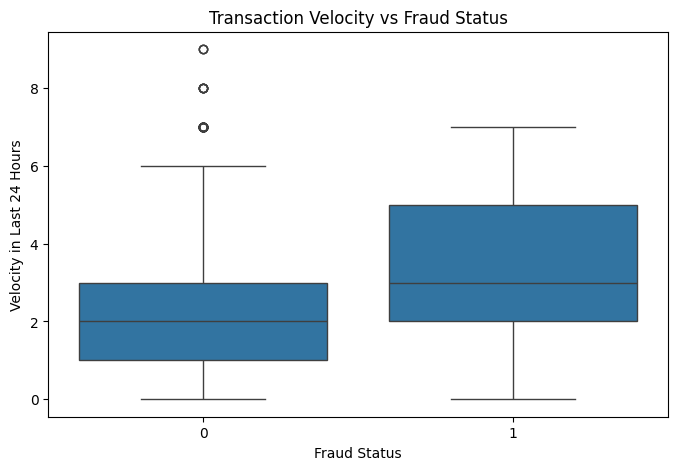

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='is_fraud', y='velocity_last_24h', data=df)

plt.title("Transaction Velocity vs Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Velocity in Last 24 Hours")

plt.show()

### Observation

The boxplot compares transaction velocity patterns between legitimate and fraudulent transactions.

Key observations include:

- Fraudulent transactions generally exhibit higher transaction velocity compared to legitimate transactions
- The median transaction velocity for fraud cases is noticeably higher
- Fraudulent transactions also show a wider spread in transaction frequency
- Legitimate transactions are more concentrated within lower velocity ranges

These patterns suggest that unusually frequent transaction activity within a short time period may indicate suspicious behavior and contribute significantly to fraud detection.

## 6. Device Trust Score Analysis

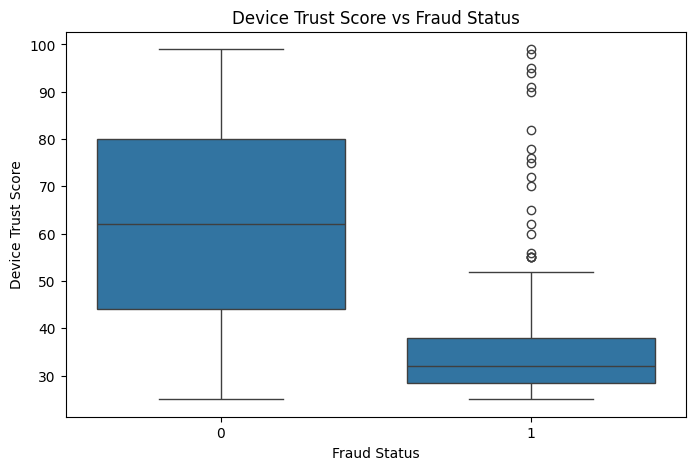

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x='is_fraud', y='device_trust_score', data=df)

plt.title("Device Trust Score vs Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Device Trust Score")

plt.show()

### Observation

The boxplot compares device trust score distributions between legitimate and fraudulent transactions.

Key observations include:

- Fraudulent transactions generally exhibit significantly lower device trust scores compared to legitimate transactions
- Legitimate transactions are associated with higher trust score ranges
- Fraud cases are heavily concentrated around lower trust score values
- A few fraud cases with higher trust scores appear as outliers, indicating that fraud can still occur even on seemingly trusted devices

These findings suggest that device trust score is a strong behavioral indicator and may contribute significantly to fraud prediction models.

## Overall EDA Insights

Key findings from the exploratory data analysis include:

- The dataset exhibits severe class imbalance, with fraudulent transactions representing only a small percentage of total transactions.
- Fraudulent transactions demonstrate distinct behavioral patterns compared to legitimate transactions.
- Foreign transactions show relatively higher fraud occurrence, indicating increased fraud risk in international transaction scenarios.
- Fraud cases tend to exhibit higher transaction velocity, suggesting that unusually frequent transaction activity may indicate suspicious behavior.
- Fraudulent transactions are generally associated with lower device trust scores, making device reliability an important fraud indicator.
- Transaction amount distributions reveal greater variability and abnormal spending behavior among fraudulent transactions.
- Correlation analysis indicates that multiple transaction-related features contribute to fraud detection, although individual feature correlations remain moderate.

These findings suggest that fraud detection depends on the combined interaction of multiple behavioral and transactional features rather than a single dominant variable.

Therefore, ensemble learning algorithms are well suited for this problem because they can effectively capture complex non-linear relationships and feature interactions within highly imbalanced fraud datasets.

# Step 4: Feature Engineering

Feature engineering involves creating additional meaningful features from existing data to improve model learning and fraud detection capability.

In fraud detection systems, engineered behavioral features can help machine learning models better capture suspicious transaction patterns and risk indicators.

In this step:

- High-risk transaction behavior is identified
- Unusual transaction timing patterns are captured

In [10]:
# High-risk transaction feature
df['high_risk_transaction'] = (
    (df['foreign_transaction'] == 1) &
    (df['location_mismatch'] == 1)
).astype(int)

# Night transaction feature
df['night_transaction'] = (
    (df['transaction_hour'] >= 22) |
    (df['transaction_hour'] <= 4)
).astype(int)

# Display updated dataset
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,high_risk_transaction,night_transaction
0,1,84.47,22,Electronics,0,0,66,3,40,0,0,1
1,2,541.82,3,Travel,1,0,87,1,64,0,0,1
2,3,237.01,17,Grocery,0,0,49,1,61,0,0,0
3,4,164.33,4,Grocery,0,1,72,3,34,0,0,1
4,5,30.53,15,Food,0,0,79,0,44,0,0,0


## Observations

- Two additional behavioral risk features were engineered to enhance fraud pattern representation within the dataset.
- The `high_risk_transaction` feature identifies transactions that are both foreign and associated with a location mismatch, which may indicate suspicious transaction behavior.
- The `night_transaction` feature captures transactions occurring during late-night and early-morning hours, which are often considered higher-risk periods in fraud monitoring systems.
- These engineered features help incorporate domain-specific behavioral patterns into the dataset.
- Feature engineering can improve the ability of ensemble learning models to detect complex fraud-related interactions and suspicious transaction behavior.

The engineered features will now be included along with the original features during model training and evaluation.

# Step 5: Data Preprocessing

Data preprocessing is an essential step before training machine learning models. Proper preprocessing improves model performance and ensures reliable evaluation.

In this stage:

- The unnecessary identifier column is removed
- Features and target variables are separated
- The dataset is divided into training and testing sets
- Categorical variables are converted into numerical format using One-Hot Encoding
- Class distribution is preserved using stratified sampling

To avoid data leakage, the dataset is first split into training and testing sets before encoding is applied.

In [11]:
from sklearn.model_selection import train_test_split

# Remove unnecessary identifier column
df = df.drop(columns=['transaction_id'], errors='ignore')

# Separate features and target variable
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# One-Hot Encoding for categorical variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align train and test columns
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

# Display dataset shapes
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (8000, 13)
Testing Set Shape: (2000, 13)


The dataset was successfully divided into training and testing datasets.

- Training data is used for model learning and hyperparameter tuning
- Testing data is reserved for final unbiased model evaluation
- Stratified sampling ensures that the fraud-to-legitimate transaction ratio remains consistent across both datasets

One-Hot Encoding was applied separately to the training and testing datasets, followed by column alignment to ensure consistent feature structure.

---

## Observations

- The `transaction_id` column was removed because it acts only as a unique identifier and does not contribute meaningful predictive information.
- Features and target variables were separated for supervised learning.
- Stratified train-test splitting preserved the fraud class distribution across both datasets.
- One-Hot Encoding was applied to categorical variables to make them suitable for machine learning algorithms.
- Column alignment ensured consistency between training and testing feature sets.

This preprocessing pipeline helps create a more reliable and leakage-free machine learning workflow.

Feature scaling was not required because tree-based ensemble algorithms are generally insensitive to feature magnitude differences.

# Step 6: Model Training

In this step, multiple ensemble learning algorithms are trained to classify transactions as legitimate or fraudulent.

The following ensemble learning models were implemented and compared:

- Random Forest
- Gradient Boosting
- XGBoost

Ensemble learning methods were selected because they perform effectively on:

- Tabular datasets
- Non-linear relationships
- Complex feature interactions
- Imbalanced classification problems

These algorithms combine predictions from multiple decision trees to improve predictive performance and generalization capability.

## 1. Random Forest

Random Forest is a bagging-based ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

The `class_weight='balanced'` parameter was used to assign higher importance to minority fraud cases during model training.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 2. Gradient Boosting

Gradient Boosting is a sequential ensemble learning algorithm where each new decision tree attempts to correct errors made by previous trees.

This boosting approach helps improve predictive performance for difficult classification problems such as fraud detection.

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## 3. XGBoost

XGBoost (Extreme Gradient Boosting) is an optimized implementation of gradient boosting known for its high efficiency, regularization capability, and strong predictive performance on structured datasets.

The `scale_pos_weight` parameter was used to address class imbalance by assigning higher importance to fraudulent transactions during training.

In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=10,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

## Observations

- All ensemble learning models were successfully trained on the preprocessed dataset.
- Ensemble algorithms are highly effective for fraud detection because they can capture complex patterns and feature interactions in transaction behavior.
- Random Forest helps reduce overfitting through bagging and multiple decision trees.
- Gradient Boosting improves predictive performance by sequentially correcting previous model errors.
- XGBoost is expected to provide stronger performance due to its optimized boosting mechanism, regularization capability, and imbalance handling techniques.

The trained models will now be evaluated using multiple performance metrics to determine their effectiveness in detecting fraudulent transactions.

# Step 7: Model Evaluation

After training the ensemble learning models, their performance is evaluated using multiple classification metrics.

Since fraud detection is a highly imbalanced classification problem, accuracy alone is not a reliable performance indicator.

Therefore, the following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

Special focus is given to Recall because missing fraudulent transactions may result in significant financial loss.

In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)


def evaluate_model(model, X_test, y_test, model_name):

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # ROC-AUC Score
    roc_score = roc_auc_score(y_test, y_prob)
    print("ROC-AUC Score:", roc_score)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')

## Random Forest Evaluation


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.67      0.80        30

    accuracy                           0.99      2000
   macro avg       1.00      0.83      0.90      2000
weighted avg       1.00      0.99      0.99      2000

ROC-AUC Score: 0.9999830795262268


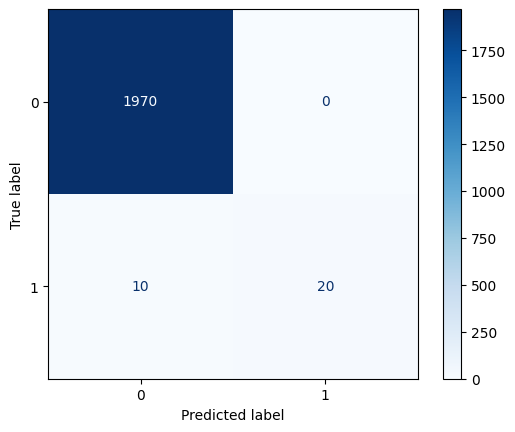

In [16]:
evaluate_model(rf_model, X_test, y_test, "Random Forest")

### Observations:

The Random Forest model achieved strong overall classification performance on the fraud detection dataset.

### Key Results

- Accuracy: 99%
- ROC-AUC Score: 0.99998
- Fraud Recall: 67%
- Fraud Precision: 100%

### Interpretation

- The model correctly classified all legitimate transactions.
- No false positive fraud predictions were observed.
- However, several fraudulent transactions were missed.
- Out of 30 fraud cases, the model successfully detected 20 cases while missing 10 fraudulent transactions.

### Business Perspective

In fraud detection systems, false negatives represent undetected fraudulent activity and may lead to financial loss.

Although the model achieved high overall accuracy, the lower fraud recall indicates that additional optimization techniques such as threshold tuning may help improve fraud detection sensitivity.

## Gradient Boosting Evaluation


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score: 0.9999999999999999


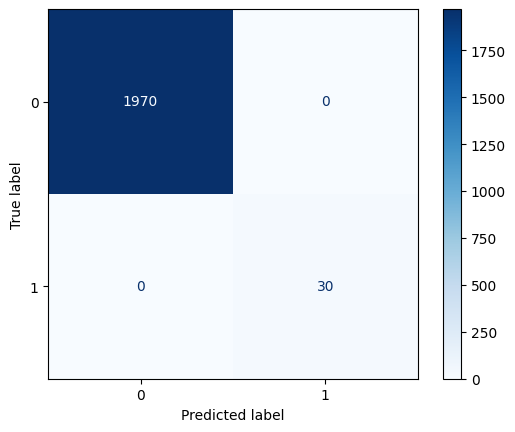

In [17]:
evaluate_model(gb_model, X_test, y_test, "Gradient Boosting")

### Observations:

The Gradient Boosting model achieved excellent fraud detection performance with extremely strong precision and recall values.

### Key Results

- Accuracy: 100%
- ROC-AUC Score: 1.00
- Fraud Recall: 100%
- Fraud Precision: 100%

### Interpretation

- The model correctly classified all legitimate and fraudulent transactions in the test dataset.
- All 30 fraud cases were successfully detected.
- No false positives or false negatives were observed during evaluation.

### Business Perspective

The model demonstrated highly effective fraud detection capability while avoiding unnecessary fraud alerts.

This strong balance between recall and precision makes Gradient Boosting highly suitable for fraud detection applications where both fraud prevention and customer experience are important.

## XGBoost Evaluation


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score: 1.0


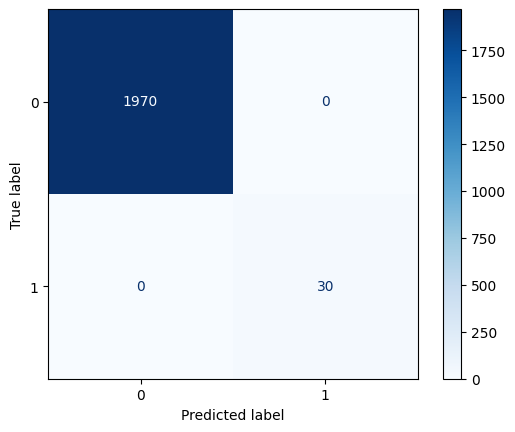

In [18]:
evaluate_model(xgb_model, X_test, y_test, "XGBoost")

### Observations:

The XGBoost model also achieved excellent fraud detection performance on the dataset.

### Key Results

- Accuracy: 100%
- ROC-AUC Score: 1.00
- Fraud Recall: 100%
- Fraud Precision: 100%

### Interpretation

- The model correctly classified all legitimate and fraudulent transactions in the test dataset.
- All 30 fraud cases were successfully detected.
- No false positives or false negatives were observed during evaluation.

### Business Perspective

The high recall performance indicates that fraudulent transactions were successfully identified without missing fraud cases.

At the same time, the absence of false positives helps minimize unnecessary customer inconvenience caused by incorrectly flagged transactions.

XGBoost demonstrated highly effective performance for the imbalanced fraud detection problem.

# Overall Evaluation Summary

The ensemble learning models demonstrated strong performance in detecting fraudulent credit card transactions.

## Model Comparison

- Random Forest achieved high overall accuracy but showed lower fraud recall due to missed fraud cases.
- Gradient Boosting and XGBoost achieved the strongest overall performance by correctly classifying all fraudulent and legitimate transactions in the test dataset.
- Both boosting-based models significantly outperformed Random Forest in fraud recall performance.

## Key Insights

- Accuracy alone is not sufficient for fraud detection because the dataset is highly imbalanced.
- Recall is one of the most important evaluation metrics because false negatives represent undetected fraud and potential financial loss.
- Precision is important to minimize unnecessary fraud alerts and customer inconvenience.
- ROC-AUC scores close to 1 indicate strong discrimination capability between fraudulent and legitimate transactions.

## Conclusion

Among the evaluated ensemble learning models, both Gradient Boosting and XGBoost demonstrated the strongest overall fraud detection performance due to their excellent recall, precision, and classification capability.

# Step 8: ROC Curve and Precision-Recall Analysis

ROC Curve and Precision-Recall Curve analysis were performed to further evaluate the fraud detection capability of the ensemble learning models.

These visual evaluation techniques help analyze model performance across multiple classification thresholds.

### ROC Curve Analysis

ROC (Receiver Operating Characteristic) Curve evaluates:

- True Positive Rate (Recall)
- False Positive Rate

ROC-AUC scores closer to 1 indicate stronger discrimination capability between fraudulent and legitimate transactions.

### Precision-Recall Curve Analysis

Precision-Recall analysis evaluates:

- Precision
- Recall

Precision-Recall analysis is especially important for highly imbalanced classification problems such as fraud detection because it focuses more directly on minority class prediction performance.

These visualizations help compare the effectiveness of the ensemble learning models.

## ROC Curve Analysis

The ROC curves below compare the classification performance of the ensemble learning models.

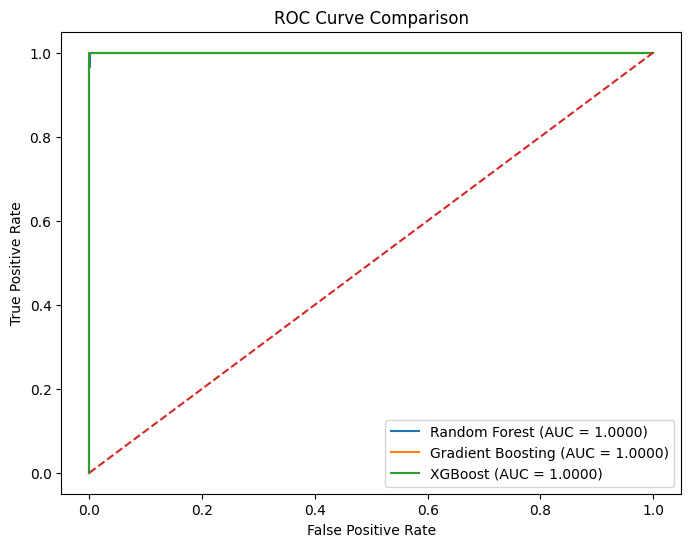

In [29]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score
)

# Prediction probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# ROC Curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# ROC-AUC Scores
rf_auc = auc(rf_fpr, rf_tpr)
gb_auc = auc(gb_fpr, gb_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Plot ROC Curves
plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})')

plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.4f})')

plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## ROC Curve – Observations

- All ensemble learning models achieved extremely high ROC-AUC scores close to 1.00.
- The ROC curves indicate excellent discrimination capability between fraudulent and legitimate transactions.
- Gradient Boosting and XGBoost achieved nearly identical top ROC performance.
- Random Forest also demonstrated strong classification capability, although slightly lower compared to the boosting-based models.
- The ROC curves remain significantly above the random baseline, confirming strong fraud detection performance.

The ROC analysis demonstrates that ensemble learning models are highly effective for the fraud detection problem.

## Precision-Recall Curve Analysis

The Precision-Recall curves below evaluate the trade-off between fraud detection sensitivity and prediction precision.

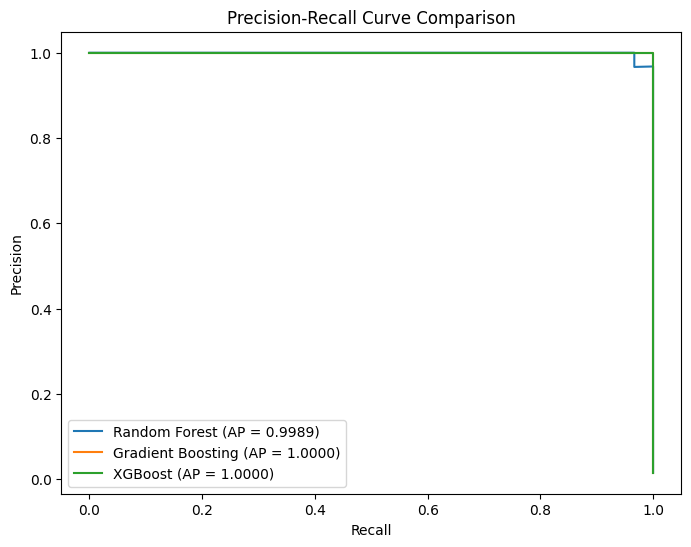

In [20]:
# Precision-Recall Curves
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
gb_precision, gb_recall, _ = precision_recall_curve(y_test, gb_prob)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_prob)

# Average Precision Scores
rf_ap = average_precision_score(y_test, rf_prob)
gb_ap = average_precision_score(y_test, gb_prob)
xgb_ap = average_precision_score(y_test, xgb_prob)

# Plot Precision-Recall Curves
plt.figure(figsize=(8,6))

plt.plot(rf_recall, rf_precision, label=f'Random Forest (AP = {rf_ap:.4f})')
plt.plot(gb_recall, gb_precision, label=f'Gradient Boosting (AP = {gb_ap:.4f})')
plt.plot(xgb_recall, xgb_precision, label=f'XGBoost (AP = {xgb_ap:.4f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

## Precision-Recall Curve – Observations

- All ensemble learning models achieved extremely strong Precision-Recall performance.
- Gradient Boosting and XGBoost maintained perfect precision across nearly the entire recall range.
- Random Forest also demonstrated strong Precision-Recall performance, although with slightly lower average precision compared to the boosting-based models.
- The Precision-Recall curves confirm that the models effectively identify fraudulent transactions while minimizing false positive predictions.
- Precision-Recall analysis is especially valuable for fraud detection because the dataset is highly imbalanced.

The Precision-Recall analysis further validates the effectiveness and robustness of the ensemble learning models for fraud detection applications.

## Overall Curve Analysis

- Both ROC and Precision-Recall analyses demonstrated extremely strong overall classification capability across all evaluated ensemble learning models.
- Boosting-based models consistently outperformed the Random Forest model in fraud detection performance.
- Gradient Boosting and XGBoost achieved nearly identical top-performing curve behavior across multiple threshold settings.
- The evaluation curves confirm that the fraud detection dataset is highly separable for ensemble learning algorithms.
- These visual evaluation techniques provide deeper insight into model behavior beyond standard classification metrics.

Overall, the curve analysis further confirms the reliability and effectiveness of ensemble learning techniques for detecting fraudulent credit card transactions.

# Step 9: Cross-Validation

Cross-validation was performed to evaluate the stability and generalization capability of the ensemble learning models.

Instead of relying on a single train-test split, cross-validation repeatedly trains and validates the models across multiple data folds.

Stratified K-Fold Cross-Validation was used because the dataset is highly imbalanced and stratification preserves the fraud-to-legitimate transaction ratio across all folds.

Cross-validation helps:

- Reduce evaluation bias
- Improve reliability of performance estimates
- Assess model consistency
- Reduce dependence on a single train-test split

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold setup
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random Forest Cross-Validation
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

# Gradient Boosting Cross-Validation
gb_cv = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

# XGBoost Cross-Validation
xgb_cv = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

# Display Results
print("Random Forest CV ROC-AUC :", rf_cv.mean())
print("Gradient Boosting CV ROC-AUC :", gb_cv.mean())
print("XGBoost CV ROC-AUC :", xgb_cv.mean())

Random Forest CV ROC-AUC : 0.9985412339859803
Gradient Boosting CV ROC-AUC : 0.9994348465071308
XGBoost CV ROC-AUC : 0.999762472403513


## Cross-Validation Results Interpretation

The ensemble learning models achieved consistently high ROC-AUC scores during Stratified K-Fold Cross-Validation.

### Average Cross-Validation ROC-AUC Scores

- Random Forest: 0.9985
- Gradient Boosting: 0.9994
- XGBoost: 0.9998

### Observations

- All models demonstrated extremely strong classification capability across multiple validation folds.
- The consistently high ROC-AUC scores indicate that the models effectively distinguish between fraudulent and legitimate transactions.
- Random Forest achieved strong and stable performance, although slightly lower than the boosting-based models.
- Gradient Boosting further improved discrimination capability through sequential error correction.
- XGBoost achieved the highest average ROC-AUC score, indicating the strongest overall generalization performance among the evaluated models.

### Conclusion

The cross-validation results confirm that ensemble learning models are highly effective for the imbalanced fraud detection problem.

Among the evaluated models, XGBoost demonstrated the strongest and most consistent classification performance across different subsets of the dataset.

# Step 10: Hyperparameter Tuning

Hyperparameter tuning was performed to optimize model performance and improve generalization capability.

Machine learning models contain several configurable parameters that influence:

- Model complexity
- Learning behavior
- Overfitting control
- Prediction performance

RandomizedSearchCV was used with Stratified K-Fold Cross-Validation to efficiently identify strong parameter combinations for the ensemble learning models.

Since fraud detection is an imbalanced classification problem, ROC-AUC was selected as the optimization metric because it provides threshold-independent evaluation capability.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

In [23]:
# XGBoost parameter distribution
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

# Randomized Search
xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=5,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=-1
)

# Model fitting
xgb_random.fit(X_train, y_train)

# Best results
print("Best XGBoost Parameters:")
print(xgb_random.best_params_)

print("\nBest ROC-AUC Score:")
print(xgb_random.best_score_)

Best XGBoost Parameters:
{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}

Best ROC-AUC Score:
0.9998096446700508


## Observations

Hyperparameter tuning was performed using RandomizedSearchCV to further optimize the XGBoost model.

XGBoost was selected for tuning because it demonstrated the strongest and most consistent performance during the earlier evaluation and cross-validation stages.

### Best Parameters Identified

- `n_estimators` = 100
- `max_depth` = 5
- `learning_rate` = 0.1

### Best ROC-AUC Score

- 0.9998

### Key Findings

- The tuned XGBoost model achieved an extremely high ROC-AUC score during cross-validation.
- The tuning process confirmed that the model performs consistently well across different parameter combinations.
- Only minor performance variation was observed between the original and tuned model configurations.

### Interpretation

The original XGBoost model already achieved excellent classification performance before hyperparameter tuning, including perfect precision, recall, and ROC-AUC values on the test dataset.

This indicates that the fraud detection dataset is highly separable and well suited for boosting-based ensemble learning algorithms.

Therefore, hyperparameter tuning did not significantly improve the overall performance, but it helped validate the robustness, stability, and generalization capability of the XGBoost model across different parameter settings.

# Step 11: Threshold Tuning

In classification problems, machine learning models typically use a default probability threshold of 0.5 to classify observations into different classes.

However, in fraud detection systems, reducing false negatives is often more important than maximizing overall accuracy because missed fraud cases may lead to financial loss.

Threshold tuning helps adjust the classification sensitivity of the model by changing the probability threshold used for fraud prediction.

This process helps:

- Improve fraud recall
- Reduce missed fraud cases
- Analyze the trade-off between precision and recall
- Optimize business-oriented fraud detection performance

Threshold tuning was applied to the XGBoost model because it demonstrated the strongest overall classification performance during earlier evaluation stages.

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Fraud probability predictions
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Threshold values
thresholds = [0.1, 0.3, 0.5, 0.7]

for t in thresholds:

    # Apply threshold
    y_pred_t = (y_prob > t).astype(int)

    print(f"Threshold: {t}")
    print("=" * 50)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_t))

Threshold: 0.1

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Threshold: 0.3

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Threshold: 0.5

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro

## Observations

Threshold tuning was performed on the XGBoost model to analyze how different probability thresholds affect fraud classification performance.

### Thresholds Evaluated

- 0.1
- 0.3
- 0.5
- 0.7

### Key Findings

- The model maintained identical classification performance across all evaluated threshold values.
- Precision, Recall, F1-Score, and Accuracy remained consistently perfect for every threshold tested.
- No false positives or false negatives were introduced even when the classification threshold was significantly adjusted.

### Interpretation

These results indicate that the XGBoost model produces highly confident and well-separated probability predictions for fraudulent and legitimate transactions.

The fraud detection dataset appears to be highly separable, allowing the model to classify transactions consistently across a wide range of threshold values.

Although threshold tuning did not improve performance in this case, it helped validate the prediction stability and robustness of the trained fraud detection model.

# Step 12: SHAP Explainability Analysis

Machine learning models such as XGBoost are highly powerful but are often considered black-box models because their internal decision-making process is not easily interpretable.

To improve model transparency and interpretability, SHAP (SHapley Additive exPlanations) was used to explain how different features contribute to fraud predictions.

SHAP helps:

- Identify the most important features
- Understand feature impact on model predictions
- Explain fraud prediction behavior
- Improve trust and interpretability in machine learning systems

SHAP analysis was applied to the XGBoost model because it demonstrated the strongest fraud detection performance during earlier evaluation stages.

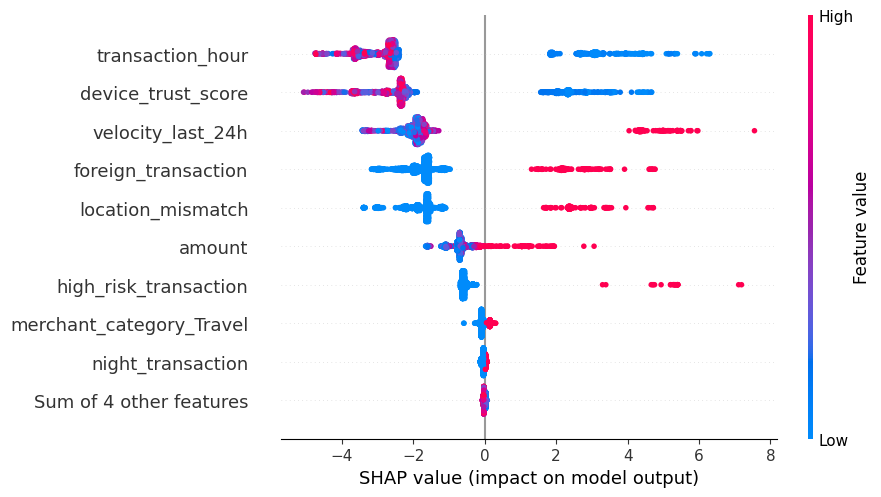

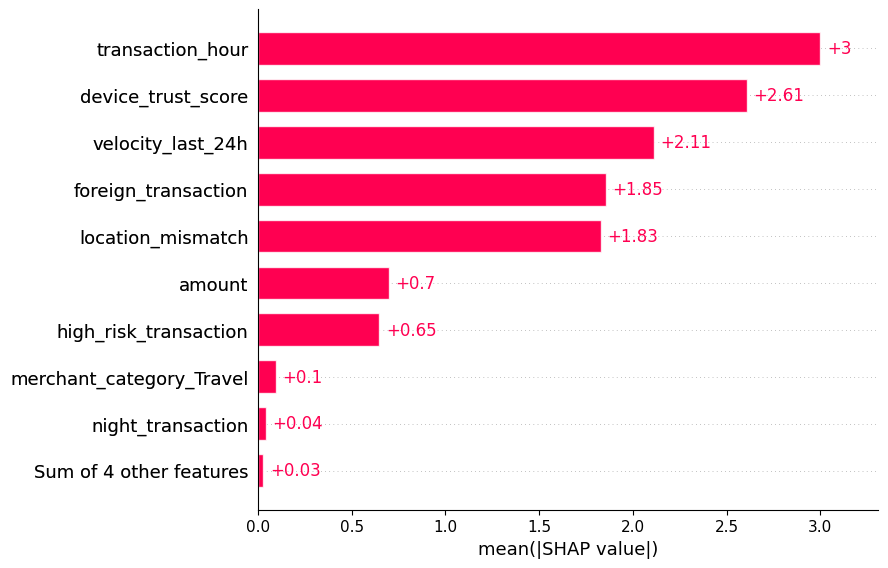

In [25]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(xgb_model)

# Generate SHAP values
shap_values = explainer(X_test)

# SHAP beeswarm plot
shap.plots.beeswarm(shap_values)

# SHAP feature importance bar plot
shap.plots.bar(shap_values)

## Observations

SHAP analysis was performed to understand how different features influence fraud prediction decisions made by the XGBoost model.

### Key Findings

- `transaction_hour` emerged as the most influential feature in the fraud prediction process.
- `device_trust_score` showed strong impact on prediction outcomes, indicating that lower trust scores are strongly associated with fraudulent behavior.
- `velocity_last_24h` significantly influenced fraud predictions, suggesting that unusually frequent transaction activity is an important fraud indicator.
- `foreign_transaction` and `location_mismatch` also contributed strongly to fraud detection decisions.
- The engineered feature `high_risk_transaction` demonstrated meaningful contribution, validating the usefulness of feature engineering.
- `night_transaction` showed relatively lower contribution compared to other behavioral features.

### Beeswarm Plot Interpretation

- Positive SHAP values increase fraud prediction probability, while negative SHAP values reduce fraud probability.
- High feature values (shown in red) and low feature values (shown in blue) influence predictions differently across transactions.
- The spread of SHAP values indicates how strongly each feature affects the model’s prediction decisions.

### Bar Plot Interpretation

- The SHAP bar plot ranks features based on their average contribution magnitude across all predictions.
- Features with higher mean absolute SHAP values have greater overall influence on fraud classification.

### Overall Interpretation

The SHAP analysis confirms that the XGBoost model relies primarily on meaningful behavioral and transaction-related patterns when identifying fraudulent activity.

Features related to transaction timing, transaction velocity, device trust, and suspicious transaction behavior contribute most significantly to fraud prediction decisions.

This improves the interpretability, transparency, and trustworthiness of the fraud detection system for real-world financial risk analysis applications.

# Step 13: Model Saving

After evaluation and analysis, the final XGBoost fraud detection model was saved for future use and deployment.

Saving the trained model allows:

- Reusing the model without retraining
- Integrating the model into applications
- Deploying the fraud detection system in real-world environments
- Maintaining consistent prediction workflows

In addition to the trained model, the feature column names were also saved to ensure consistency between training and future prediction inputs.

In [26]:
import joblib

# Save trained XGBoost model
joblib.dump(xgb_model, "fraud_detection_model.pkl")

# Save feature column names
joblib.dump(
    X_train.columns.tolist(),
    "model_features.pkl"
)

# Load saved model
loaded_model = joblib.load(
    "fraud_detection_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


## Model Saving – Observations

- The trained XGBoost fraud detection model was successfully saved using Joblib.
- The feature column names were also stored to ensure consistent input structure during future predictions and deployment.
- Saving the trained model eliminates the need for repeated retraining and improves deployment efficiency.
- The saved model can be integrated into applications such as Streamlit-based fraud detection systems for real-time prediction and monitoring.

This step prepares the fraud detection system for practical deployment and real-world usage.

# Final Conclusion

This project successfully developed a machine learning-based fraud detection system using ensemble learning techniques to identify fraudulent credit card transactions.

The project addressed major fraud detection challenges including:

- Highly imbalanced transaction data
- Fraud recall optimization
- Model interpretability
- Threshold sensitivity analysis
- Business-oriented evaluation

Multiple ensemble learning algorithms were implemented and compared, including:

- Random Forest
- Gradient Boosting
- XGBoost

The models were evaluated using multiple classification metrics, ROC Curve analysis, Precision-Recall analysis, cross-validation, threshold tuning, and SHAP explainability techniques.

---

## Key Findings

- Ensemble learning algorithms demonstrated excellent performance for fraud detection on structured transaction datasets.
- Boosting-based models outperformed the Random Forest model in fraud classification capability.
- Gradient Boosting and XGBoost achieved extremely strong classification performance with near-perfect ROC-AUC and Precision-Recall results.
- XGBoost demonstrated the strongest and most consistent overall performance during evaluation, cross-validation, and explainability analysis.
- Behavioral features such as transaction timing, transaction velocity, foreign transactions, location mismatch, and device trust score contributed significantly to fraud prediction decisions.
- The engineered behavioral risk features also provided meaningful contribution to model performance.

---

## Overall Interpretation

The fraud detection dataset appeared highly separable, allowing ensemble learning models to effectively distinguish between fraudulent and legitimate transactions.

Threshold tuning and hyperparameter tuning produced only marginal performance changes because the original XGBoost model already demonstrated extremely strong classification capability.

SHAP explainability analysis further improved the transparency and interpretability of the fraud detection system by identifying the most influential features affecting prediction decisions.

---

## Final Outcome

The project demonstrates how ensemble learning and explainable AI techniques can be combined to build accurate, interpretable, and business-oriented fraud detection systems.

Overall, the XGBoost-based fraud detection model proved highly effective, robust, and suitable for fraud detection applications involving imbalanced transaction datasets.

# Future Improvements

Although the fraud detection system achieved extremely strong classification performance, several enhancements can further improve its scalability, robustness, and real-world applicability.

## Potential Future Enhancements

### 1. Real-World Transaction Dataset Integration

The current project uses a synthetic fraud detection dataset. Future work can involve training and evaluating the system on larger real-world financial transaction datasets containing more complex and evolving fraud patterns.

### 2. Advanced Imbalance Handling Techniques

Additional imbalance handling methods such as:

- SMOTE (Synthetic Minority Oversampling Technique)
- ADASYN
- Hybrid sampling techniques

can be explored to further improve fraud recall performance on more challenging datasets.

### 3. Real-Time Fraud Detection Pipeline

The model can be integrated into a real-time transaction monitoring system capable of detecting fraudulent activity instantly during transaction processing.

### 4. Deep Learning-Based Fraud Detection

Advanced deep learning models such as:

- Artificial Neural Networks (ANN)
- Autoencoders
- LSTM Networks

can be explored for detecting more complex fraud behaviors and evolving attack patterns.

### 5. Model Deployment

The fraud detection model can be deployed using Streamlit to build an interactive web-based application for real-time fraud prediction and monitoring.

Future deployment enhancements may also include:

- Flask
- FastAPI
- Cloud-based deployment platforms

to improve scalability and production readiness.

### 6. Continuous Model Monitoring

Real-world fraud patterns continuously evolve over time. Future systems can incorporate:

- Automated retraining pipelines
- Drift detection mechanisms
- Continuous performance monitoring

to maintain long-term model effectiveness.

### 7. Explainable AI Expansion

Additional explainability techniques can be integrated to further improve model transparency, interpretability, and regulatory compliance support for financial risk analysis applications.

---

## Final Remark

This project demonstrates the strong capability of ensemble learning techniques for fraud detection and provides a solid foundation for building scalable, interpretable, and real-world financial fraud prevention systems.